* **Accuracy (Dokładność):** Całkowity odsetek poprawnych predykcji. Pokazuje, jak często algorytm miał rację ogółem, ale może być mylący, jeśli rynek przez większość czasu poruszał się tylko w jednym kierunku (np. trwała silna hossa).
* **Balanced Acc (Zbilansowana Dokładność):** Średnia skuteczność wyliczana osobno dla trafionych wzrostów i trafionych spadków. Bezlitośnie weryfikuje, czy model potrafi grać na obu kierunkach rynku, niwelując wpływ długoterminowych trendów.
* **F1-Score:** Wskaźnik łączący precyzję (jak pewny jest sygnał, gdy algorytm mówi "kup") z czułością (ile z faktycznych wzrostów algorytm zdołał wyłapać). Bardzo dobrze ocenia stabilność i jakość sygnałów transakcyjnych.
* **AUC (Area Under the Curve):** Zdolność rozdzielcza modelu. Mierzy, jak dobrze algorytm separuje od siebie sygnały wzrostowe i spadkowe na podstawie wektorów prawdopodobieństwa. Wynik 0.5 to rzut monetą.
* **MCC (Matthews Correlation Coefficient):** Najbardziej rygorystyczna miara statystyczna w tabeli (zakres od -1 do 1). Wymaga poprawnego wyłapywania zarówno sukcesów, jak i błędów obu klas. Wynik powyżej 0 udowadnia obiektywną, matematyczną przewagę algorytmu nad rynkiem (lepiej niż losowe zgadywanie).

Hub Pekao + Obligacje

>>> Przygotowano dane. Tygodni do przetworzenia: 563
>>> Brak pliku końcowego. Przygotowywanie obwodów kwantowych...
>>> Udane połączenie z procesorem: IQMBackend. Transpilacja...
  Wysyłanie i obliczanie paczki 1 / 34...
  Wysyłanie i obliczanie paczki 2 / 34...
  Wysyłanie i obliczanie paczki 3 / 34...
  Wysyłanie i obliczanie paczki 4 / 34...
  Wysyłanie i obliczanie paczki 5 / 34...
  Wysyłanie i obliczanie paczki 6 / 34...
  Wysyłanie i obliczanie paczki 7 / 34...
  Wysyłanie i obliczanie paczki 8 / 34...
  Wysyłanie i obliczanie paczki 9 / 34...
  Wysyłanie i obliczanie paczki 10 / 34...
  Wysyłanie i obliczanie paczki 11 / 34...
  Wysyłanie i obliczanie paczki 12 / 34...
  Wysyłanie i obliczanie paczki 13 / 34...


Progress in queue:   0%|          | 0/1 [01:22<?, ?it/s]


  Wysyłanie i obliczanie paczki 14 / 34...
  Wysyłanie i obliczanie paczki 15 / 34...
  Wysyłanie i obliczanie paczki 16 / 34...
  Wysyłanie i obliczanie paczki 17 / 34...
  Wysyłanie i obliczanie paczki 18 / 34...
  Wysyłanie i obliczanie paczki 19 / 34...
  Wysyłanie i obliczanie paczki 20 / 34...
  Wysyłanie i obliczanie paczki 21 / 34...
  Wysyłanie i obliczanie paczki 22 / 34...
  Wysyłanie i obliczanie paczki 23 / 34...
  Wysyłanie i obliczanie paczki 24 / 34...
  Wysyłanie i obliczanie paczki 25 / 34...
  Wysyłanie i obliczanie paczki 26 / 34...
  Wysyłanie i obliczanie paczki 27 / 34...
  Wysyłanie i obliczanie paczki 28 / 34...
  Wysyłanie i obliczanie paczki 29 / 34...
  Wysyłanie i obliczanie paczki 30 / 34...


Progress in queue:   0%|          | 0/1 [01:22<?, ?it/s]


  Wysyłanie i obliczanie paczki 31 / 34...
  Wysyłanie i obliczanie paczki 32 / 34...
  Wysyłanie i obliczanie paczki 33 / 34...
  Wysyłanie i obliczanie paczki 34 / 34...

>>> Pobrano wszystkie wyniki z QPU! Obliczanie wartości oczekiwanych...
>>> Zapisano ostateczny plik: phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz

>>> Start ewaluacji Walk-Forward dla Quantum SVM (Standalone)...

--- FINALNE WYNIKI PUBLIKACYJNE ---


,Accuracy,Balanced Acc,F1,AUC,MCC
Ultimate QPU Odra SVM (Standalone),0.5401,0.5239,0.6228,0.5147,0.0507


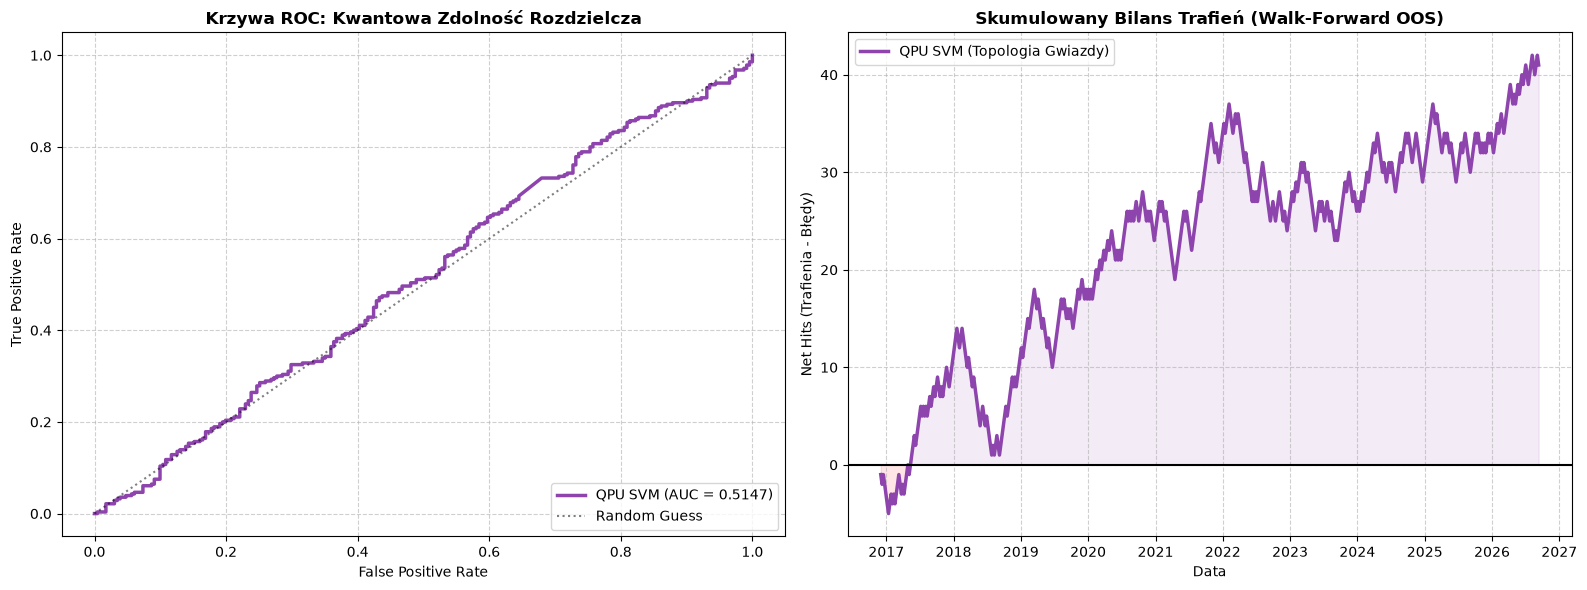

In [1]:
%matplotlib inline

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef
)
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         
    'pbv_peo', 'rentownosc_10y',   
    'pbv_san', 'eurpln',           
    'pbv_ing', 'wig20',            
    'pbv_mbk', 'zmiennosc'         
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

print(f">>> Przygotowano dane. Tygodni do przetworzenia: {len(X_quantum)}")

# ==========================================
# 2. GENEROWANIE RZUTÓW Z SYSTEMEM CHECKPOINTÓW
# ==========================================
HUB_QUBIT = 1

def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def build_measurement_circuits(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc_x = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits, hub_qubit)
    qc_z.measure_all()
    return qc_x, qc_y, qc_z

def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_secure_qpu_projections(X_q, dates_arr, features_arr, filepath, num_qubits=5, reps=1, shots=4000, batch_size=50):
    if os.path.exists(filepath):
        print(f">>> Znaleziono gotowy plik końcowy: {filepath}. Ładowanie cache...")
        return np.load(filepath, allow_pickle=True)["phi"]
        
    print(f">>> Brak pliku końcowego. Przygotowywanie obwodów kwantowych...")
    all_circuits = []
    for x in X_q: 
        all_circuits.extend(build_measurement_circuits(x, num_qubits, HUB_QUBIT))
        
    try:
        from dotenv import load_dotenv
        env_paths = ["../iqm_token.env", "iqm_token.env", "token.env", "../token.env"]
        for path in env_paths:
            if os.path.exists(path):
                load_dotenv(path)
                break
        server_url = os.getenv("SERVER")
        if not server_url: raise ValueError("Brak adresu URL do serwera IQM.")
        
        try:
            from iqm.qiskit import IQMProvider
        except ImportError:
            from iqm.qiskit_iqm import IQMProvider
            
        provider = IQMProvider(server_url)
        backend = provider.get_backend()
        print(f">>> Udane połączenie z procesorem: {backend.name}. Transpilacja...")
        transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
        
    except Exception as e:
        print(f"\n[!] Błąd połączenia z API QPU.")
        print(">>> Przełączam na symulator (AerSimulator)...")
        backend = AerSimulator()
        transpiled = transpile(all_circuits, backend=backend)
        
    # --- SYSTEM CHECKPOINTÓW ---
    checkpoint_file = "qpu_checkpoint.pkl"
    all_counts = []
    
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, "rb") as f:
            all_counts = pickle.load(f)
        print(f"\n>>> ZNALEZIONO CHECKPOINT! Wznawianie pracy.")
        print(f">>> Pobrane dotychczas obwody: {len(all_counts)} / {len(transpiled)}")
    
    start_idx = len(all_counts)
    
    for i in range(start_idx, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"  Wysyłanie i obliczanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1}...")
        
        try:
            job = backend.run(batch, shots=shots)
            for j in range(len(batch)): 
                all_counts.append(job.result().get_counts(j))
                
            # Zapisz postęp na dysku po każdej pomyślnie przetworzonej paczce
            with open(checkpoint_file, "wb") as f:
                pickle.dump(all_counts, f)
                
        except Exception as e:
            print(f"\n🚨 BŁĄD API SERWERA PODCZAS POBIERANIA WYNIKÓW (Paczka {i//batch_size + 1}).")
            print(f"🚨 Twój postęp ({len(all_counts)} obwodów) jest bezpieczny w pliku '{checkpoint_file}'.")
            print(f"🚨 Przerwij działanie komórki i uruchom kod ponownie za kilka minut, aby wznowić dokładnie od tego miejsca.\n")
            raise e 
            
    if len(all_counts) < len(transpiled):
        raise RuntimeError("Wykryto brakujące dane pomiarowe. Uruchom skrypt ponownie, aby dokończyć pobieranie.")
            
    print("\n>>> Pobrano wszystkie wyniki z QPU! Obliczanie wartości oczekiwanych...")
    Phi_odra = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    backend_name = getattr(backend, "name", "aer_simulator")
    np.savez(filepath, phi=Phi_odra, dates=dates_arr, features=np.array(features_arr), reps=reps, shots=shots, num_qubits=num_qubits, backend=backend_name)
    
    # Skoro dotarliśmy tutaj, zrzut pamięci nie jest już potrzebny
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
        
    print(f">>> Zapisano ostateczny plik: {filepath}")
    return Phi_odra

cache_filename = "phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz"
Phi_real = get_secure_qpu_projections(X_quantum, dates, FEATURES_MAP, cache_filename, reps=1)

# ==========================================
# 3. KROCZĄCY TRENING MODELU QPU (Z PLATT SCALINGIEM)
# ==========================================
def make_q_svm_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True, random_state=42))])

param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}
inner_cv = TimeSeriesSplit(n_splits=3)
TRAIN_WINDOW = 52
n_samples = len(y)

results = {"y_true": [], "dates": [], "prob_qpu": []}

print("\n>>> Start ewaluacji Walk-Forward dla Quantum SVM (Standalone)...")

for t in range(TRAIN_WINDOW, n_samples):
    P_tr, P_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    search_qpu = GridSearchCV(make_q_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1)
    search_qpu.fit(P_tr, y_tr)
    
    results["prob_qpu"].append(search_qpu.predict_proba(P_te)[0, 1])

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
prob_qpu = results["prob_qpu"]
pred_qpu = (prob_qpu > 0.5).astype(int) 

# ==========================================
# 4. METRYKI I WIZUALIZACJA
# ==========================================
def compute_metrics(y_t, pred, probs):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Acc": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, probs),
        "MCC": matthews_corrcoef(y_t, pred)
    }

metrics = compute_metrics(y_true, pred_qpu, prob_qpu)
df_metrics = pd.DataFrame({"Ultimate QPU Odra SVM (Standalone)": metrics}).T

print("\n--- FINALNE WYNIKI PUBLIKACYJNE ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fpr, tpr, _ = roc_curve(y_true, prob_qpu)

ax[0].plot(fpr, tpr, color='#8e44ad', lw=2.5, label=f'QPU SVM (AUC = {metrics["AUC"]:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random Guess')
ax[0].set_title('Krzywa ROC: Kwantowa Zdolność Rozdzielcza', fontweight='bold', fontsize=12)
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.6)

net_hits = np.cumsum(np.where(pred_qpu == y_true, 1, -1))
ax[1].plot(results["dates"], net_hits, color='#8e44ad', lw=2.5, label='QPU SVM (Topologia Gwiazdy)')
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Walk-Forward OOS)', fontweight='bold', fontsize=12)
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].legend(loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.6)

ax[1].fill_between(results["dates"], 0, net_hits, where=(net_hits > 0), color='#8e44ad', alpha=0.1)
ax[1].fill_between(results["dates"], 0, net_hits, where=(net_hits <= 0), color='red', alpha=0.1)

plt.tight_layout()
plt.show()

Hub Mbank i zmienność

>>> Przygotowano dane. Tygodni do przetworzenia: 563
>>> Brak pliku końcowego. Przygotowywanie obwodów kwantowych...
>>> Udane połączenie z procesorem: IQMBackend. Transpilacja...
  Wysyłanie i obliczanie paczki 1 / 34...
  Wysyłanie i obliczanie paczki 2 / 34...
  Wysyłanie i obliczanie paczki 3 / 34...
  Wysyłanie i obliczanie paczki 4 / 34...
  Wysyłanie i obliczanie paczki 5 / 34...
  Wysyłanie i obliczanie paczki 6 / 34...
  Wysyłanie i obliczanie paczki 7 / 34...
  Wysyłanie i obliczanie paczki 8 / 34...
  Wysyłanie i obliczanie paczki 9 / 34...
  Wysyłanie i obliczanie paczki 10 / 34...
  Wysyłanie i obliczanie paczki 11 / 34...
  Wysyłanie i obliczanie paczki 12 / 34...
  Wysyłanie i obliczanie paczki 13 / 34...
  Wysyłanie i obliczanie paczki 14 / 34...
  Wysyłanie i obliczanie paczki 15 / 34...
  Wysyłanie i obliczanie paczki 16 / 34...
  Wysyłanie i obliczanie paczki 17 / 34...
  Wysyłanie i obliczanie paczki 18 / 34...
  Wysyłanie i obliczanie paczki 19 / 34...
  Wysyłanie 

,Accuracy,Balanced Acc,F1,AUC,MCC
Quantum SVM (QPU HUB 4),0.5499,0.5374,0.6192,0.5344,0.0773
Classical SVM (Raw Features),0.5421,0.5291,0.6139,0.5125,0.0603


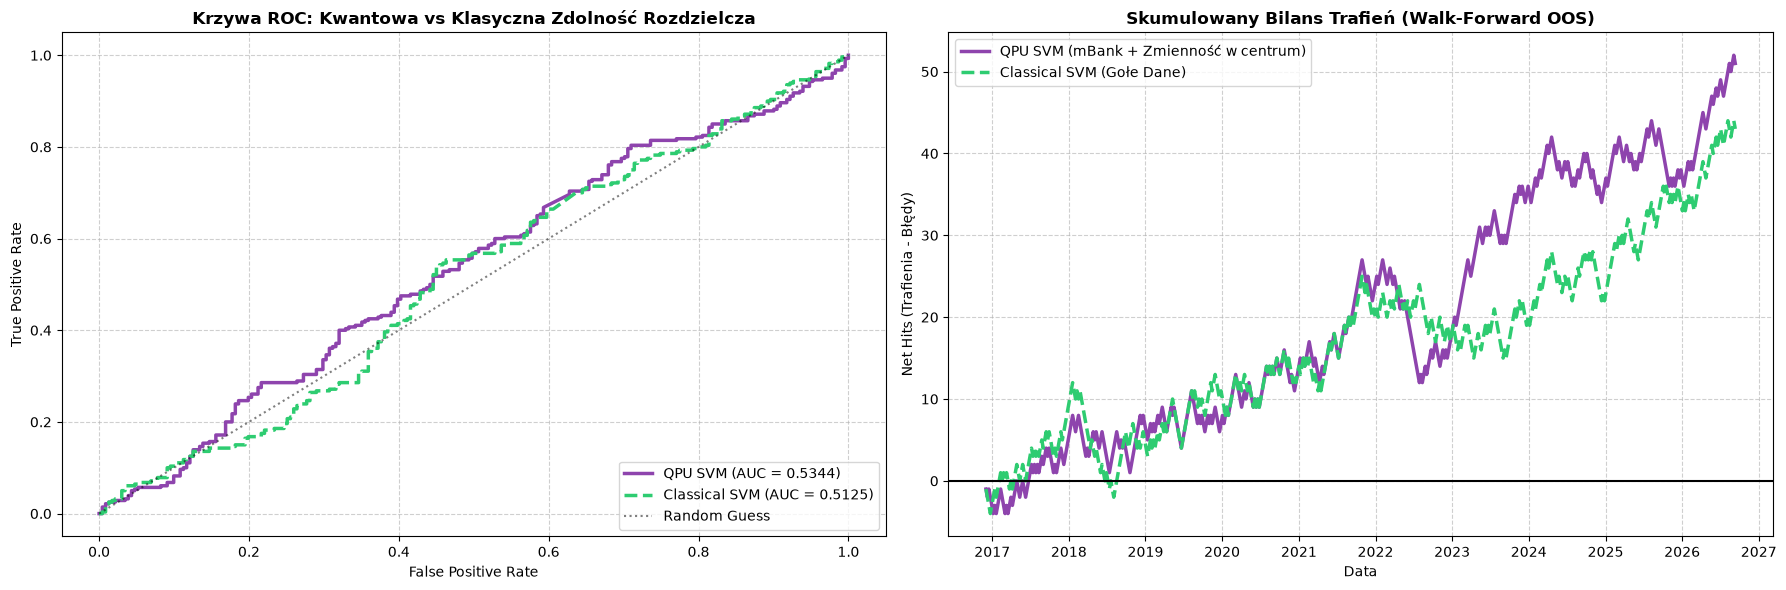

In [2]:
%matplotlib inline

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef
)
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0
    'pbv_peo', 'rentownosc_10y',   # Kubit 1
    'pbv_san', 'eurpln',           # Kubit 2
    'pbv_ing', 'wig20',            # Kubit 3
    'pbv_mbk', 'zmiennosc'         # Kubit 4 (HUB)
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

print(f">>> Przygotowano dane. Tygodni do przetworzenia: {len(X_quantum)}")

# ==========================================
# 2. GENEROWANIE RZUTÓW Z SYSTEMEM CHECKPOINTÓW
# ==========================================
HUB_QUBIT = 4

def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def build_measurement_circuits(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc_x = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits, hub_qubit)
    qc_z.measure_all()
    return qc_x, qc_y, qc_z

def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_secure_qpu_projections(X_q, dates_arr, features_arr, filepath, num_qubits=5, reps=1, shots=4000, batch_size=50):
    if os.path.exists(filepath):
        print(f">>> Znaleziono gotowy plik końcowy: {filepath}. Ładowanie cache...")
        return np.load(filepath, allow_pickle=True)["phi"]
        
    print(f">>> Brak pliku końcowego. Przygotowywanie obwodów kwantowych...")
    all_circuits = []
    for x in X_q: 
        all_circuits.extend(build_measurement_circuits(x, num_qubits, HUB_QUBIT))
        
    try:
        from dotenv import load_dotenv
        env_paths = ["../iqm_token.env", "iqm_token.env", "token.env", "../token.env"]
        for path in env_paths:
            if os.path.exists(path):
                load_dotenv(path)
                break
        server_url = os.getenv("SERVER")
        if not server_url: raise ValueError("Brak adresu URL do serwera IQM.")
        
        try:
            from iqm.qiskit import IQMProvider
        except ImportError:
            from iqm.qiskit_iqm import IQMProvider
            
        provider = IQMProvider(server_url)
        backend = provider.get_backend()
        print(f">>> Udane połączenie z procesorem: {backend.name}. Transpilacja...")
        transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
        
    except Exception as e:
        print(f"\n[!] Błąd połączenia z API QPU.")
        print(">>> Przełączam na symulator (AerSimulator)...")
        backend = AerSimulator()
        transpiled = transpile(all_circuits, backend=backend)
        
    checkpoint_file = f"qpu_checkpoint_hub{HUB_QUBIT}.pkl"
    all_counts = []
    
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, "rb") as f:
            all_counts = pickle.load(f)
        print(f"\n>>> ZNALEZIONO CHECKPOINT! Wznawianie pracy.")
        print(f">>> Pobrane dotychczas obwody: {len(all_counts)} / {len(transpiled)}")
    
    start_idx = len(all_counts)
    
    for i in range(start_idx, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"  Wysyłanie i obliczanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1}...")
        
        try:
            job = backend.run(batch, shots=shots)
            for j in range(len(batch)): 
                all_counts.append(job.result().get_counts(j))
                
            with open(checkpoint_file, "wb") as f:
                pickle.dump(all_counts, f)
                
        except Exception as e:
            print(f"\n🚨 BŁĄD API SERWERA PODCZAS POBIERANIA WYNIKÓW (Paczka {i//batch_size + 1}).")
            print(f"🚨 Twój postęp jest bezpieczny w pliku '{checkpoint_file}'.\n")
            raise e 
            
    if len(all_counts) < len(transpiled):
        raise RuntimeError("Wykryto brakujące dane pomiarowe. Uruchom skrypt ponownie.")
            
    print("\n>>> Pobrano wszystkie wyniki z QPU! Obliczanie wartości oczekiwanych...")
    Phi_odra = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    backend_name = getattr(backend, "name", "aer_simulator")
    np.savez(filepath, phi=Phi_odra, dates=dates_arr, features=np.array(features_arr), reps=reps, shots=shots, num_qubits=num_qubits, backend=backend_name)
    
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
        
    print(f">>> Zapisano ostateczny plik: {filepath}")
    return Phi_odra

cache_filename = "phi_odra_wigbanki_5q_star_HUB4_reps1_shots4000.npz"
Phi_real = get_secure_qpu_projections(X_quantum, dates, FEATURES_MAP, cache_filename, reps=1)

# ==========================================
# 3. KROCZĄCY TRENING (QPU vs KLASYKA)
# ==========================================
def make_svm_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True, random_state=42))])

param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}
inner_cv = TimeSeriesSplit(n_splits=3)
TRAIN_WINDOW = 52
n_samples = len(y)

results = {"y_true": [], "dates": [], "prob_qpu": [], "prob_cls": []}

print("\n>>> Start ewaluacji Walk-Forward: Quantum SVM (HUB 4) vs Classical SVM...")

for t in range(TRAIN_WINDOW, n_samples):
    # Dane dla QPU
    P_tr, P_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    # Dane dla Klasycznego SVM
    X_tr_cls, X_te_cls = X_raw_valid[t - TRAIN_WINDOW : t], X_raw_valid[t : t + 1]
    
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # Trening i ewaluacja Quantum SVM
    search_qpu = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1)
    search_qpu.fit(P_tr, y_tr)
    results["prob_qpu"].append(search_qpu.predict_proba(P_te)[0, 1])

    # Trening i ewaluacja Klasycznego SVM
    search_cls = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1)
    search_cls.fit(X_tr_cls, y_tr)
    results["prob_cls"].append(search_cls.predict_proba(X_te_cls)[0, 1])

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
prob_qpu = results["prob_qpu"]
prob_cls = results["prob_cls"]

pred_qpu = (prob_qpu > 0.5).astype(int) 
pred_cls = (prob_cls > 0.5).astype(int) 

# ==========================================
# 4. METRYKI I WIZUALIZACJA PORÓWNAWCZA
# ==========================================
def compute_metrics(y_t, pred, probs):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Acc": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, probs),
        "MCC": matthews_corrcoef(y_t, pred)
    }

metrics_qpu = compute_metrics(y_true, pred_qpu, prob_qpu)
metrics_cls = compute_metrics(y_true, pred_cls, prob_cls)

df_metrics = pd.DataFrame({
    "Quantum SVM (QPU HUB 4)": metrics_qpu,
    "Classical SVM (Raw Features)": metrics_cls
}).T

print("\n--- FINALNE WYNIKI PUBLIKACYJNE ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Krzywa ROC
fpr_qpu, tpr_qpu, _ = roc_curve(y_true, prob_qpu)
fpr_cls, tpr_cls, _ = roc_curve(y_true, prob_cls)

ax[0].plot(fpr_qpu, tpr_qpu, color='#8e44ad', lw=2.5, label=f'QPU SVM (AUC = {metrics_qpu["AUC"]:.4f})')
ax[0].plot(fpr_cls, tpr_cls, color='#2ecc71', lw=2.5, linestyle='--', label=f'Classical SVM (AUC = {metrics_cls["AUC"]:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random Guess')
ax[0].set_title('Krzywa ROC: Kwantowa vs Klasyczna Zdolność Rozdzielcza', fontweight='bold', fontsize=12)
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Skumulowany Bilans Trafień (Equity Curve)
net_hits_qpu = np.cumsum(np.where(pred_qpu == y_true, 1, -1))
net_hits_cls = np.cumsum(np.where(pred_cls == y_true, 1, -1))

ax[1].plot(results["dates"], net_hits_qpu, color='#8e44ad', lw=2.5, label='QPU SVM (mBank + Zmienność w centrum)')
ax[1].plot(results["dates"], net_hits_cls, color='#2ecc71', lw=2.5, linestyle='--', label='Classical SVM (Gołe Dane)')
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Walk-Forward OOS)', fontweight='bold', fontsize=12)
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].legend(loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Hub PKO + Wibor

>>> Przygotowano dane dla HUB_QUBIT = 0. Tygodni: 563
>>> Brak pliku końcowego. Przygotowywanie obwodów kwantowych...
>>> Udane połączenie z procesorem: IQMBackend. Transpilacja...

>>> ZNALEZIONO CHECKPOINT! Wznawianie pracy z pliku: qpu_checkpoint_hub0_base.pkl
>>> Pobrane dotychczas obwody: 300 / 1689
  Wysyłanie i obliczanie paczki 7 / 34...
  Wysyłanie i obliczanie paczki 8 / 34...
  Wysyłanie i obliczanie paczki 9 / 34...


Progress in queue:   0%|          | 0/1 [01:22<?, ?it/s]


  Wysyłanie i obliczanie paczki 10 / 34...
  Wysyłanie i obliczanie paczki 11 / 34...
  Wysyłanie i obliczanie paczki 12 / 34...
  Wysyłanie i obliczanie paczki 13 / 34...
  Wysyłanie i obliczanie paczki 14 / 34...
  Wysyłanie i obliczanie paczki 15 / 34...
  Wysyłanie i obliczanie paczki 16 / 34...
  Wysyłanie i obliczanie paczki 17 / 34...
  Wysyłanie i obliczanie paczki 18 / 34...
  Wysyłanie i obliczanie paczki 19 / 34...
  Wysyłanie i obliczanie paczki 20 / 34...
  Wysyłanie i obliczanie paczki 21 / 34...
  Wysyłanie i obliczanie paczki 22 / 34...


Progress in queue:   0%|          | 0/1 [01:22<?, ?it/s]


  Wysyłanie i obliczanie paczki 23 / 34...
  Wysyłanie i obliczanie paczki 24 / 34...
  Wysyłanie i obliczanie paczki 25 / 34...
  Wysyłanie i obliczanie paczki 26 / 34...
  Wysyłanie i obliczanie paczki 27 / 34...
  Wysyłanie i obliczanie paczki 28 / 34...
  Wysyłanie i obliczanie paczki 29 / 34...
  Wysyłanie i obliczanie paczki 30 / 34...
  Wysyłanie i obliczanie paczki 31 / 34...
  Wysyłanie i obliczanie paczki 32 / 34...
  Wysyłanie i obliczanie paczki 33 / 34...
  Wysyłanie i obliczanie paczki 34 / 34...

>>> Pobrano wszystkie wyniki z QPU! Obliczanie wartości oczekiwanych...
>>> Zapisano ostateczny plik: phi_odra_wigbanki_5q_star_HUB0_base_reps1_shots4000.npz

>>> Start ewaluacji Walk-Forward: Quantum SVM (HUB 0) vs Classical SVM...

--- FINALNE WYNIKI PUBLIKACYJNE ---


,Accuracy,Balanced Acc,F1,AUC,MCC
Quantum SVM (QPU HUB 0),0.5440,0.5294,0.6211,0.5177,0.0616
Classical SVM (Raw Features),0.5421,0.5291,0.6139,0.5125,0.0603


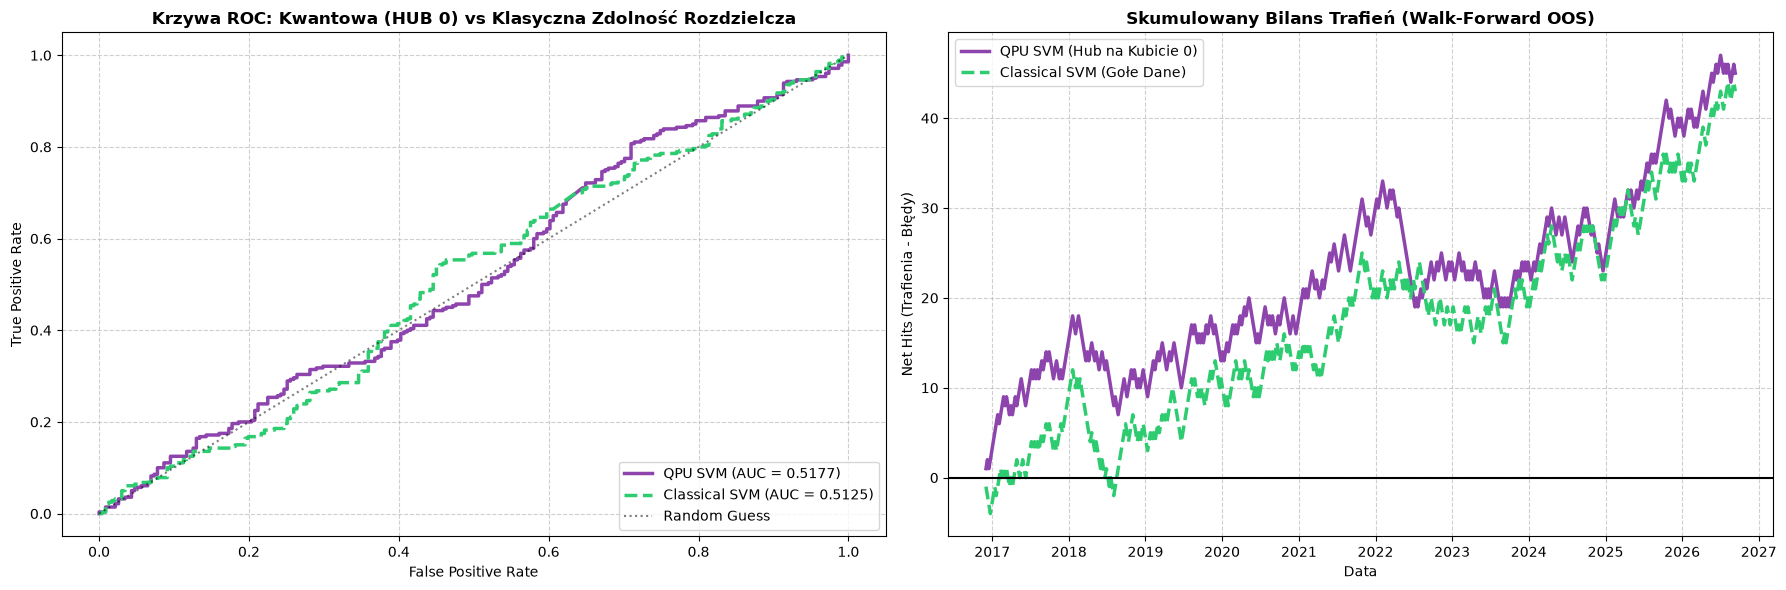

In [2]:
%matplotlib inline

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef
)
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0 
    'pbv_peo', 'rentownosc_10y',   # Kubit 1
    'pbv_san', 'eurpln',           # Kubit 2
    'pbv_ing', 'wig20',            # Kubit 3
    'pbv_mbk', 'zmiennosc'         # Kubit 4 
]

# TĘ ZMIENNĄ ZMIENIASZ W KAŻDEJ KOMÓRCE JUPYTERA:
HUB_QUBIT = 0

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

print(f">>> Przygotowano dane dla HUB_QUBIT = {HUB_QUBIT}. Tygodni: {len(X_quantum)}")

# ==========================================
# 2. GENEROWANIE RZUTÓW Z SYSTEMEM CHECKPOINTÓW
# ==========================================
def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def build_measurement_circuits(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc_x = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits, hub_qubit)
    qc_z.measure_all()
    return qc_x, qc_y, qc_z

def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_secure_qpu_projections(X_q, dates_arr, features_arr, filepath, num_qubits=5, reps=1, shots=4000, batch_size=50):
    if os.path.exists(filepath):
        print(f">>> Znaleziono gotowy plik końcowy: {filepath}. Ładowanie cache...")
        return np.load(filepath, allow_pickle=True)["phi"]
        
    print(f">>> Brak pliku końcowego. Przygotowywanie obwodów kwantowych...")
    all_circuits = []
    for x in X_q: 
        all_circuits.extend(build_measurement_circuits(x, num_qubits, HUB_QUBIT))
        
    try:
        from dotenv import load_dotenv
        env_paths = ["../iqm_token.env", "iqm_token.env", "token.env", "../token.env"]
        for path in env_paths:
            if os.path.exists(path):
                load_dotenv(path)
                break
        server_url = os.getenv("SERVER")
        if not server_url: raise ValueError("Brak adresu URL do serwera IQM.")
        
        try:
            from iqm.qiskit import IQMProvider
        except ImportError:
            from iqm.qiskit_iqm import IQMProvider
            
        provider = IQMProvider(server_url)
        backend = provider.get_backend()
        print(f">>> Udane połączenie z procesorem: {backend.name}. Transpilacja...")
        transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
        
    except Exception as e:
        print(f"\n[!] Błąd połączenia z API QPU.")
        print(">>> Przełączam na symulator (AerSimulator)...")
        backend = AerSimulator()
        transpiled = transpile(all_circuits, backend=backend)
        
    # Unikalny plik checkpointu dla DANEGO HUB_QUBIT:
    checkpoint_file = f"qpu_checkpoint_hub{HUB_QUBIT}_base.pkl"
    all_counts = []
    
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, "rb") as f:
            all_counts = pickle.load(f)
        print(f"\n>>> ZNALEZIONO CHECKPOINT! Wznawianie pracy z pliku: {checkpoint_file}")
        print(f">>> Pobrane dotychczas obwody: {len(all_counts)} / {len(transpiled)}")
    
    start_idx = len(all_counts)
    
    for i in range(start_idx, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"  Wysyłanie i obliczanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1}...")
        
        try:
            job = backend.run(batch, shots=shots)
            for j in range(len(batch)): 
                all_counts.append(job.result().get_counts(j))
                
            with open(checkpoint_file, "wb") as f:
                pickle.dump(all_counts, f)
                
        except Exception as e:
            print(f"\n🚨 BŁĄD API SERWERA PODCZAS POBIERANIA WYNIKÓW (Paczka {i//batch_size + 1}).")
            print(f"🚨 Twój postęp jest bezpieczny w pliku '{checkpoint_file}'.\n")
            raise e 
            
    if len(all_counts) < len(transpiled):
        raise RuntimeError("Wykryto brakujące dane pomiarowe. Uruchom skrypt ponownie.")
            
    print("\n>>> Pobrano wszystkie wyniki z QPU! Obliczanie wartości oczekiwanych...")
    Phi_odra = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    backend_name = getattr(backend, "name", "aer_simulator")
    np.savez(filepath, phi=Phi_odra, dates=dates_arr, features=np.array(features_arr), reps=reps, shots=shots, num_qubits=num_qubits, backend=backend_name)
    
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
        
    print(f">>> Zapisano ostateczny plik: {filepath}")
    return Phi_odra

# Unikalna nazwa pliku wyjściowego .npz dla konkretnego huba
cache_filename = f"phi_odra_wigbanki_5q_star_HUB{HUB_QUBIT}_base_reps1_shots4000.npz"
Phi_real = get_secure_qpu_projections(X_quantum, dates, FEATURES_MAP, cache_filename, reps=1)

# ==========================================
# 3. KROCZĄCY TRENING (QPU vs KLASYKA)
# ==========================================
def make_svm_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True, random_state=42))])

param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}
inner_cv = TimeSeriesSplit(n_splits=3)
TRAIN_WINDOW = 52
n_samples = len(y)

results = {"y_true": [], "dates": [], "prob_qpu": [], "prob_cls": []}

print(f"\n>>> Start ewaluacji Walk-Forward: Quantum SVM (HUB {HUB_QUBIT}) vs Classical SVM...")

for t in range(TRAIN_WINDOW, n_samples):
    # Dane dla QPU
    P_tr, P_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    # Dane dla Klasycznego SVM
    X_tr_cls, X_te_cls = X_raw_valid[t - TRAIN_WINDOW : t], X_raw_valid[t : t + 1]
    
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # Trening i ewaluacja Quantum SVM
    search_qpu = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1)
    search_qpu.fit(P_tr, y_tr)
    results["prob_qpu"].append(search_qpu.predict_proba(P_te)[0, 1])

    # Trening i ewaluacja Klasycznego SVM
    search_cls = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1)
    search_cls.fit(X_tr_cls, y_tr)
    results["prob_cls"].append(search_cls.predict_proba(X_te_cls)[0, 1])

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
prob_qpu = results["prob_qpu"]
prob_cls = results["prob_cls"]

pred_qpu = (prob_qpu > 0.5).astype(int) 
pred_cls = (prob_cls > 0.5).astype(int) 

# ==========================================
# 4. METRYKI I WIZUALIZACJA PORÓWNAWCZA
# ==========================================
def compute_metrics(y_t, pred, probs):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Acc": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, probs),
        "MCC": matthews_corrcoef(y_t, pred)
    }

metrics_qpu = compute_metrics(y_true, pred_qpu, prob_qpu)
metrics_cls = compute_metrics(y_true, pred_cls, prob_cls)

df_metrics = pd.DataFrame({
    f"Quantum SVM (QPU HUB {HUB_QUBIT})": metrics_qpu,
    "Classical SVM (Raw Features)": metrics_cls
}).T

print("\n--- FINALNE WYNIKI PUBLIKACYJNE ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Krzywa ROC
fpr_qpu, tpr_qpu, _ = roc_curve(y_true, prob_qpu)
fpr_cls, tpr_cls, _ = roc_curve(y_true, prob_cls)

ax[0].plot(fpr_qpu, tpr_qpu, color='#8e44ad', lw=2.5, label=f'QPU SVM (AUC = {metrics_qpu["AUC"]:.4f})')
ax[0].plot(fpr_cls, tpr_cls, color='#2ecc71', lw=2.5, linestyle='--', label=f'Classical SVM (AUC = {metrics_cls["AUC"]:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random Guess')
ax[0].set_title(f'Krzywa ROC: Kwantowa (HUB {HUB_QUBIT}) vs Klasyczna Zdolność Rozdzielcza', fontweight='bold', fontsize=12)
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Skumulowany Bilans Trafień (Equity Curve)
net_hits_qpu = np.cumsum(np.where(pred_qpu == y_true, 1, -1))
net_hits_cls = np.cumsum(np.where(pred_cls == y_true, 1, -1))

ax[1].plot(results["dates"], net_hits_qpu, color='#8e44ad', lw=2.5, label=f'QPU SVM (Hub na Kubicie {HUB_QUBIT})')
ax[1].plot(results["dates"], net_hits_cls, color='#2ecc71', lw=2.5, linestyle='--', label='Classical SVM (Gołe Dane)')
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Walk-Forward OOS)', fontweight='bold', fontsize=12)
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].legend(loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()